모델 배포 개론 05  
Last modified : 2026.06    
작성 : 박광석 (모두의연구소)  
수정 : 김지성 (모두의연구소)

In [ ]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
# ✅ 수정본: 필요한 패키지/폴더/공통 모듈을 먼저 준비한 뒤 서버를 실행합니다.

import os, sys, asyncio, threading, time, socket, contextlib, subprocess, importlib.util
from pathlib import Path

# 작업 디렉터리를 app/ 가 있는 위치로 맞춥니다 (notebooks/ 안에서 열어도 동작).
if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# 코드를 저장할 폴더를 미리 만들어 둡니다.
for _d in ('app', 'models', 'data', 'frontend'):
    os.makedirs(_d, exist_ok=True)

# 패키지 폴더로 인식되도록 __init__.py 생성
Path('app/__init__.py').touch()

# 필요한 패키지가 없으면 현재 커널 환경에 설치합니다.
def _ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f'📦 {pip_name} 설치 중...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

for _import_name, _pip_name in [
    ('fastapi', 'fastapi'),
    ('uvicorn', 'uvicorn'),
    ('requests', 'requests'),
    ('pydantic', 'pydantic'),
]:
    _ensure_package(_import_name, _pip_name)

import uvicorn

# housing_api.py가 import하는 공통 모듈 생성
# 이전 Day 파일이 없어도 이 노트북 하나만으로 실행되게 만드는 보강입니다.
Path('app/logger_config.py').write_text('import logging\nimport sys\n\n\ndef setup_logger(name: str = "app"):\n    logger = logging.getLogger(name)\n    logger.setLevel(logging.INFO)\n    logger.propagate = False\n    if not logger.handlers:\n        handler = logging.StreamHandler(sys.stdout)\n        formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(name)s | %(message)s")\n        handler.setFormatter(formatter)\n        logger.addHandler(handler)\n    return logger\n', encoding='utf-8')
Path('app/error_handlers.py').write_text('from fastapi import FastAPI, Request\nfrom fastapi.responses import JSONResponse\nfrom fastapi.exceptions import RequestValidationError\nfrom starlette.exceptions import HTTPException as StarletteHTTPException\n\n\ndef register_error_handlers(app: FastAPI):\n    @app.exception_handler(RequestValidationError)\n    async def validation_exception_handler(request: Request, exc: RequestValidationError):\n        return JSONResponse(\n            status_code=422,\n            content={"success": False, "error": "validation_error", "detail": exc.errors()},\n        )\n\n    @app.exception_handler(StarletteHTTPException)\n    async def http_exception_handler(request: Request, exc: StarletteHTTPException):\n        return JSONResponse(\n            status_code=exc.status_code,\n            content={"success": False, "error": "http_error", "detail": exc.detail},\n        )\n\n    @app.exception_handler(Exception)\n    async def unhandled_exception_handler(request: Request, exc: Exception):\n        return JSONResponse(\n            status_code=500,\n            content={"success": False, "error": "internal_server_error", "detail": str(exc)},\n        )\n', encoding='utf-8')
Path('app/middleware.py').write_text('import time\nfrom starlette.middleware.base import BaseHTTPMiddleware\n\n\nclass RequestLoggingMiddleware(BaseHTTPMiddleware):\n    async def dispatch(self, request, call_next):\n        start = time.time()\n        response = await call_next(request)\n        response.headers["X-Process-Time"] = str(round(time.time() - start, 4))\n        return response\n', encoding='utf-8')

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다."""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def _clear_app_modules():
    """노트북에서 파일을 다시 저장한 뒤 최신 코드가 import되도록 app.* 캐시를 정리합니다."""
    for name in list(sys.modules):
        if name == 'app' or name.startswith('app.'):
            sys.modules.pop(name, None)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.housing_api:app' 같은 import 경로.
    같은 포트에 이 노트북이 띄운 서버가 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if _port_open(host, port):
        print(f'⚠️ 포트 {port}를 다른 프로세스가 사용 중입니다.')
        print('   다른 노트북/터미널의 서버를 종료하거나, port=8001처럼 다른 포트를 사용하세요.')
        return None

    if isinstance(app, str):
        _clear_app_modules()

    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None

    def _run():
        if sys.platform == 'win32':
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())

    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)

    for _ in range(80):
        if _port_open(host, port):
            print(f'✅ 서버 실행됨: http://{host}:{port}')
            return server
        time.sleep(0.25)

    print('❌ 서버가 시작되지 않았습니다. 위 로그를 확인하세요.')
    return server

def wait_for_api(url='http://127.0.0.1:8000/health', timeout=20):
    """API가 실제 응답할 때까지 기다립니다."""
    import requests
    start = time.time()
    last_error = None
    while time.time() - start < timeout:
        try:
            resp = requests.get(url, timeout=2)
            if resp.status_code < 500:
                print(f'✅ API 응답 확인: HTTP {resp.status_code} — {resp.text[:200]}')
                return resp
            last_error = f'HTTP {resp.status_code}: {resp.text[:200]}'
        except Exception as e:
            last_error = repr(e)
        time.sleep(0.5)
    raise RuntimeError(f'API가 {timeout}초 안에 준비되지 않았습니다. 마지막 오류: {last_error}')

print('✅ 서버 도우미 준비 완료 (serve_in_thread, stop_server, wait_for_api)')


✅ 서버 도우미 준비 완료 (serve_in_thread, stop_server, wait_for_api)


# Day 5 — [프로젝트 1] 정형 데이터 예측 서비스

## 1. 프로젝트 개요: 정형 데이터 기반 예측 서비스 설계

---

> **학습 목표**
> - 프로젝트 1의 전체 구조와 최종 결과물을 파악합니다.
> - 캘리포니아 주택 가격 데이터셋을 이해합니다.
> - Day 1~4에서 배운 기술이 프로젝트에서 어떻게 조합되는지 미리 봅니다.

---



### 1.1 오늘 만들 것

Day 1~4까지 MNIST 예제로 조각들을 익혔습니다.
오늘은 **새로운 데이터, 새로운 모델**로 전체 파이프라인을 처음부터 끝까지 직접 구축합니다.

```
[최종 결과물]

브라우저에서:
  1. 주택 정보(면적, 방 수, 위치 등)를 입력합니다.
  2. "가격 예측" 버튼을 누릅니다.
  3. 예상 주택 가격이 표시됩니다.

내부 구조:
  Streamlit (입력 폼) → FastAPI (추론 API) → PyTorch 모델 (가격 예측)
```

---

### 1.2 데이터셋: 캘리포니아 주택 가격

scikit-learn에 내장된 `California Housing` 데이터셋을 사용합니다.
별도 다운로드가 필요 없고, 정형 데이터 예측의 대표적인 예제입니다.

In [ ]:
%pip install scikit-learn


In [ ]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
print(f"샘플 수: {data.data.shape[0]:,}")
print(f"피처 수: {data.data.shape[1]}")
print(f"타겟: {data.target_names}")
print(f"\n피처 목록:")
for i, name in enumerate(data.feature_names):
    print(f"  {i+1}. {name}")

샘플 수: 20,640
피처 수: 8
타겟: ['MedHouseVal']

피처 목록:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude


```
샘플 수: 20,640
피처 수: 8
타겟: ['MedHouseVal']

피처 목록:
  1. MedInc      — 중위 소득
  2. HouseAge    — 주택 연식
  3. AveRooms    — 평균 방 수
  4. AveBedrms   — 평균 침실 수
  5. Population  — 인구
  6. AveOccup    — 평균 거주 인원
  7. Latitude    — 위도
  8. Longitude   — 경도
```

- **입력**: 8개 피처 (숫자)
- **출력**: 중위 주택 가격 (단위: $100,000)
- **태스크**: 회귀 (Regression)

> MNIST(Day 1~4)는 이미지 분류였고, 이번 프로젝트는 **정형 데이터 회귀**입니다.
> 데이터 형태가 다르므로 전처리, 스키마, UI가 모두 달라집니다.

---



### 1.3 프로젝트 구조

```
model-serving-course/
├── 📁 app/
│   ├── model_utils.py          ← Day 1~4에서 만든 것 (MNIST용, 오늘은 건드리지 않음)
│   ├── schemas.py              ← Day 2에서 만든 것 (MNIST용, 오늘은 건드리지 않음)
│   ├── ...
│   │
│   ├── housing_model.py        ← 🆕 주택 가격 모델 정의 + 추론 함수
│   ├── housing_schemas.py      ← 🆕 주택 가격 API 스키마
│   └── housing_api.py          ← 🆕 주택 가격 FastAPI 서버
│
├── 📁 frontend/
│   ├── app_dashboard.py        ← Day 4에서 만든 것 (MNIST용)
│   └── app_housing.py          ← 🆕 주택 가격 Streamlit 대시보드
│
├── 📁 models/
│   ├── mnist_state_dict.pth    ← Day 1에서 만든 것
│   ├── housing_model.pth       ← 🆕 주택 가격 모델 가중치
│   └── housing_preprocessing.json ← 🆕 전처리 파라미터 (모델과 함께 배포)
│
└── 📁 notebooks/
    └── day5_project1.ipynb     ← 🆕 오늘의 노트북
```

> 기존 MNIST 파일은 건드리지 않습니다.
> 프로젝트 1의 파일은 모두 `housing_` 접두사를 붙여서 구분합니다.

---



### 1.4 전체 워크플로우

```
[섹션 2] 모델 준비
    │  데이터 로드 → 전처리 → PyTorch 모델 학습 → 저장
    ▼
[섹션 3] FastAPI 백엔드
    │  Pydantic 스키마 → 추론 엔드포인트 → 비동기 처리
    ▼
[섹션 4] Streamlit 프론트엔드
    │  입력 폼 → API 호출 → 결과 시각화
    ▼
[섹션 5] 통합 테스트
    │  정상 요청 / 에러 요청 / 동시 요청 테스트
    ▼
[섹션 6] 회고
```

각 섹션에서 Day 1~4의 어떤 기술이 사용되는지:



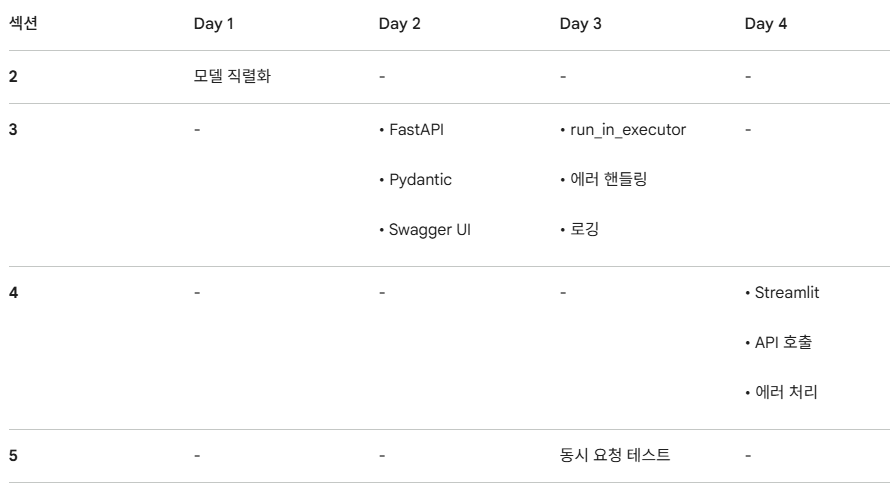

---

### 1.5 시작하기 전에

> ⚠️ **이번 프로젝트의 코드에는 `# *your code*` 주석이 포함되어 있습니다.**
>
> 지금은 전체 코드가 제공되므로 그대로 실행하시면 됩니다.
>
> `# *your code*` 옆의 코드를 직접 작성할 수 있는지 스스로 점검해 보세요.

---

### ✅ 체크포인트

1. 이 프로젝트의 입력과 출력은 각각 무엇입니까?
2. MNIST 프로젝트와 비교했을 때, 데이터 형태가 어떻게 다릅니까?
3. 오늘 새로 만들 파일 3개의 이름과 역할을 말할 수 있습니까?

---

> **다음 섹션에서는** 캘리포니아 주택 가격 데이터를 로드하고,
> PyTorch 모델을 학습하여 저장합니다.

## 2. 모델 준비: 학습 → 전처리 파이프라인 → 저장

---

> **학습 목표**
> - 캘리포니아 주택 데이터를 로드하고 탐색합니다.
> - 전처리(정규화) 파이프라인을 구성합니다.
> - PyTorch로 회귀 모델을 학습하고 저장합니다.
> - 추론 함수를 모듈로 분리합니다.

---



### 2.1 데이터 로드 및 탐색

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 데이터 로드
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"피처 크기: {X.shape}")        # (20640, 8)
print(f"타겟 크기: {y.shape}")        # (20640,)
print(f"타겟 범위: {y.min():.2f} ~ {y.max():.2f} ($100,000 단위)")
print(f"\n피처별 통계:")
for i, name in enumerate(feature_names):
    print(f"  {name:12s}  평균: {X[:, i].mean():10.2f}  표준편차: {X[:, i].std():10.2f}")

피처 크기: (20640, 8)
타겟 크기: (20640,)
타겟 범위: 0.15 ~ 5.00 ($100,000 단위)

피처별 통계:
  MedInc        평균:       3.87  표준편차:       1.90
  HouseAge      평균:      28.64  표준편차:      12.59
  AveRooms      평균:       5.43  표준편차:       2.47
  AveBedrms     평균:       1.10  표준편차:       0.47
  Population    평균:    1425.48  표준편차:    1132.43
  AveOccup      평균:       3.07  표준편차:      10.39
  Latitude      평균:      35.63  표준편차:       2.14
  Longitude     평균:    -119.57  표준편차:       2.00


In [ ]:
# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # *your code* — test_size와 random_state 설정
)

print(f"학습 데이터: {X_train.shape[0]:,}개")
print(f"테스트 데이터: {X_test.shape[0]:,}개")

학습 데이터: 16,512개
테스트 데이터: 4,128개


---

### 2.2 전처리: 정규화

피처마다 값의 범위가 크게 다릅니다 (소득: 0~15, 인구: 0~35,000).
모델 학습이 안정적으로 수렴하려면 **정규화(Normalization)**가 필요합니다.

In [ ]:
# 학습 데이터의 평균/표준편차 계산 (테스트 데이터에는 학습 데이터의 통계를 사용)
train_mean = X_train.mean(axis=0)  # *your code* — 축(axis) 설정
train_std = X_train.std(axis=0)    # *your code* — 축(axis) 설정

print("피처별 평균:", np.round(train_mean, 2))
print("피처별 표준편차:", np.round(train_std, 2))

피처별 평균: [ 3.88000e+00  2.86100e+01  5.44000e+00  1.10000e+00  1.42645e+03
  3.10000e+00  3.56400e+01 -1.19580e+02]
피처별 표준편차: [1.90000e+00 1.26000e+01 2.39000e+00 4.30000e-01 1.13702e+03 1.15800e+01
 2.14000e+00 2.01000e+00]


In [ ]:
# 정규화 적용
X_train_norm = (X_train - train_mean) / train_std  # *your code* — 정규화 공식
X_test_norm = (X_test - train_mean) / train_std     # 테스트에도 학습 데이터의 통계 사용

print(f"정규화 후 학습 데이터 평균: {X_train_norm.mean(axis=0).round(4)}")  # 거의 0
print(f"정규화 후 학습 데이터 표준편차: {X_train_norm.std(axis=0).round(4)}")  # 거의 1

정규화 후 학습 데이터 평균: [-0. -0.  0. -0. -0. -0.  0. -0.]
정규화 후 학습 데이터 표준편차: [1. 1. 1. 1. 1. 1. 1. 1.]


> ⚠️ **왜 학습 데이터의 통계로 테스트 데이터를 정규화합니까?**
>
> 테스트 데이터는 "실제 배포 환경에서 들어올 새로운 데이터"를 시뮬레이션합니다.
> 새로운 데이터의 통계를 미리 알 수 없으므로, 학습 데이터의 통계를 사용합니다.
> 이 평균/표준편차 값은 배포 시에도 함께 저장해야 합니다.

In [ ]:
# 텐서 변환
X_train_tensor = torch.FloatTensor(X_train_norm)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)  # *your code* — (N,) → (N,1)
X_test_tensor = torch.FloatTensor(X_test_norm)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

print(f"X_train 텐서: {X_train_tensor.shape}")  # torch.Size([16512, 8])
print(f"y_train 텐서: {y_train_tensor.shape}")  # torch.Size([16512, 1])

X_train 텐서: torch.Size([16512, 8])
y_train 텐서: torch.Size([16512, 1])


---

### 2.3 모델 정의 및 학습

In [ ]:
class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델 (회귀)"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),   # *your code* — 입력 차원 → 64
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),           # *your code* — 32 → 1 (회귀 출력)
        )

    def forward(self, x):
        return self.network(x)

model = HousingModel(input_dim=8)
print(f"모델 구조:\n{model}")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

모델 구조:
HousingModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
파라미터 수: 2,689


In [ ]:
# 학습 설정
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

criterion = nn.MSELoss()                                          # *your code* — 회귀이므로 MSELoss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)         # *your code* — Adam 옵티마이저

EPOCHS = 50

In [ ]:
# 학습 루프
model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)          # *your code* — 순전파
        loss = criterion(predictions, y_batch) # *your code* — 손실 계산
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    if epoch % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch:3d}/{EPOCHS} — Loss: {avg_loss:.4f}")

Epoch  10/50 — Loss: 0.5321
Epoch  20/50 — Loss: 0.4906
Epoch  30/50 — Loss: 0.4426
Epoch  40/50 — Loss: 0.4098
Epoch  50/50 — Loss: 0.3888


In [ ]:
# 테스트 평가
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_loss = criterion(test_preds, y_test_tensor)

    # MAE (Mean Absolute Error) 계산
    mae = torch.abs(test_preds - y_test_tensor).mean().item()

print(f"테스트 MSE:  {test_loss.item():.4f}")
print(f"테스트 MAE:  {mae:.4f} ($100,000 단위)")
print(f"테스트 MAE:  ${mae * 100000:,.0f} (실제 금액)")

테스트 MSE:  0.3314
테스트 MAE:  0.3892 ($100,000 단위)
테스트 MAE:  $38,916 (실제 금액)


---

### 2.4 모델 및 전처리 파라미터 저장

In [ ]:
import os
os.makedirs("models", exist_ok=True)

# 모델 가중치 저장
torch.save(model.state_dict(), "models/housing_model.pth")  # *your code* — state_dict 저장
print(f"✅ 모델 저장: models/housing_model.pth ({os.path.getsize('models/housing_model.pth')/1024:.1f} KB)")

# 전처리 파라미터 저장 (배포 시 필수!)
preprocessing_params = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "feature_names": feature_names,
}

import json
with open("models/housing_preprocessing.json", "w") as f:
    json.dump(preprocessing_params, f, indent=2)

print(f"✅ 전처리 파라미터 저장: models/housing_preprocessing.json")

✅ 모델 저장: models/housing_model.pth (13.7 KB)
✅ 전처리 파라미터 저장: models/housing_preprocessing.json


> ⚠️ **전처리 파라미터를 반드시 함께 저장해야 합니다.**
>
> 모델만 저장하고 `train_mean`, `train_std`를 저장하지 않으면,
> 배포 환경에서 정규화를 할 수 없어 잘못된 예측이 나옵니다.
> Day 1에서 ".pth 파일만 전달하면 안 된다"고 배운 것과 같은 맥락입니다.

---



### 2.5 추론 모듈 작성

Day 1에서 `app/model_utils.py`를 만든 것과 동일한 패턴입니다.

In [ ]:
%%writefile app/housing_model.py
"""
Day 5 - 주택 가격 예측 모델 정의 + 추론 함수
"""
import json
import torch
import torch.nn as nn
import numpy as np


class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


class HousingPredictor:
    """모델 로드 + 전처리 + 추론을 캡슐화한 클래스"""

    def __init__(self, model_path: str, preprocessing_path: str):
        # 전처리 파라미터 로드
        with open(preprocessing_path, "r") as f:
            params = json.load(f)
        self.mean = np.array(params["mean"])
        self.std = np.array(params["std"])
        self.feature_names = params["feature_names"]

        # 모델 로드
        self.model = HousingModel(input_dim=len(self.feature_names))
        self.model.load_state_dict(
            torch.load(model_path, map_location="cpu", weights_only=True)
        )
        self.model.eval()

    def predict(self, features: dict) -> dict:
        """
        피처 딕셔너리를 받아 가격을 예측합니다.

        Args:
            features: {"MedInc": 3.5, "HouseAge": 25, ...}
        Returns:
            {"predicted_price": 2.35, "predicted_price_usd": 235000}
        """
        # 피처를 올바른 순서로 배열
        values = [features[name] for name in self.feature_names]  # *your code* — 피처 순서 맞추기

        # 정규화
        values = np.array(values, dtype=np.float32)
        normalized = (values - self.mean) / self.std              # *your code* — 정규화 적용

        # 추론
        input_tensor = torch.FloatTensor(normalized).unsqueeze(0)  # (1, 8)
        with torch.no_grad():
            output = self.model(input_tensor)

        price = output.item()
        price = max(price, 0.0)  # 음수 방지

        return {
            "predicted_price": round(price, 4),
            "predicted_price_usd": int(price * 100000),
        }

Writing app/housing_model.py


In [ ]:
# 모듈 테스트
import sys
sys.path.insert(0, ".")

from app.housing_model import HousingPredictor

predictor = HousingPredictor(
    model_path="models/housing_model.pth",
    preprocessing_path="models/housing_preprocessing.json",
)

# 테스트 데이터의 첫 번째 샘플로 테스트
sample_features = {name: float(X_test[0, i]) for i, name in enumerate(feature_names)}
print(f"입력 피처: {sample_features}")

result = predictor.predict(sample_features)
print(f"예측 가격: ${result['predicted_price_usd']:,}")
print(f"실제 가격: ${int(y_test[0] * 100000):,}")

입력 피처: {'MedInc': 1.6812, 'HouseAge': 25.0, 'AveRooms': 4.192200557103064, 'AveBedrms': 1.0222841225626742, 'Population': 1392.0, 'AveOccup': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01}
예측 가격: $56,182
실제 가격: $47,700


---

### ✅ 체크포인트

1. 정규화에서 학습 데이터의 통계를 테스트 데이터에도 사용하는 이유는 무엇입니까?
2. 모델 가중치 외에 **함께 저장해야 하는 것**은 무엇이고, 왜 필요합니까?
3. `HousingPredictor.predict()`에서 피처를 `self.feature_names` 순서로 배열하는 이유는?

---

> **다음 섹션에서는** 이 `HousingPredictor`를 FastAPI 엔드포인트에 연결합니다.


## 3. FastAPI 백엔드: 추론 엔드포인트 + Pydantic 스키마

---

> **학습 목표**
> - 주택 가격 예측용 Pydantic 스키마를 설계합니다.
> - FastAPI 엔드포인트를 구현하고 비동기 처리를 적용합니다.
> - Swagger UI에서 API를 테스트합니다.

---


### 3.1 Pydantic 스키마 설계

In [ ]:
%%writefile app/housing_schemas.py
"""
Day 5 - 주택 가격 예측 API 스키마
"""
from pydantic import BaseModel, Field


class HousingRequest(BaseModel):
    """주택 가격 예측 요청"""
    MedInc: float = Field(..., gt=0, description="중위 소득")                        # *your code* — gt=0 설정
    HouseAge: float = Field(..., ge=0, le=100, description="주택 연식 (년)")          # *your code* — ge, le 범위
    AveRooms: float = Field(..., gt=0, description="평균 방 수")
    AveBedrms: float = Field(..., gt=0, description="평균 침실 수")
    Population: float = Field(..., gt=0, description="인구")
    AveOccup: float = Field(..., gt=0, description="평균 거주 인원")
    Latitude: float = Field(..., ge=32, le=42, description="위도 (캘리포니아 범위)")   # *your code* — 캘리포니아 위도 범위
    Longitude: float = Field(..., ge=-125, le=-114, description="경도 (캘리포니아 범위)")

    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "MedInc": 3.5,
                    "HouseAge": 25.0,
                    "AveRooms": 5.0,
                    "AveBedrms": 1.0,
                    "Population": 1500.0,
                    "AveOccup": 3.0,
                    "Latitude": 37.5,
                    "Longitude": -122.0,
                }
            ]
        }
    }


class HousingResponse(BaseModel):
    """주택 가격 예측 응답"""
    success: bool = Field(description="요청 처리 성공 여부")
    predicted_price: float = Field(description="예측 가격 ($100,000 단위)")
    predicted_price_usd: int = Field(description="예측 가격 (USD)")
    input_features: dict = Field(description="입력된 피처 값")

Writing app/housing_schemas.py


> Day 2에서 배운 `Field()`를 그대로 활용합니다.  
> 캘리포니아 데이터이므로 위도/경도에 범위 제한을 넣어 잘못된 입력을 방지합니다.

---



### 3.2 FastAPI 서버 구현

In [ ]:
%%writefile app/housing_api.py
"""
Day 5 - 주택 가격 예측 FastAPI 서버
"""
import asyncio
from contextlib import asynccontextmanager
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, HTTPException

from app.housing_schemas import HousingRequest, HousingResponse
from app.housing_model import HousingPredictor
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("housing_api")

# 추론 전용 스레드풀 (Day 3에서 배운 패턴)
inference_executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="housing")  # *your code* — 스레드풀 생성

# ===== 모델 로드 =====
MODEL_PATH = "models/housing_model.pth"
PREPROCESS_PATH = "models/housing_preprocessing.json"
predictor = None


# ===== 수명 주기(lifespan): 시작 시 모델 로드 (구 @app.on_event 대체) =====
@asynccontextmanager
async def lifespan(app: FastAPI):
    global predictor
    logger.info("주택 가격 모델 로드 중...")
    predictor = HousingPredictor(MODEL_PATH, PREPROCESS_PATH)  # *your code* — HousingPredictor 인스턴스 생성
    logger.info("모델 로드 완료")
    yield
    # (서버 종료 시 정리할 자원이 있으면 yield 뒤에 작성)


app = FastAPI(
    title="California Housing Price API",
    description="캘리포니아 주택 가격을 예측하는 API",
    version="1.0.0",
    lifespan=lifespan,
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if predictor is not None else "loading",
        "model": "California Housing",
    }


@app.post("/predict", response_model=HousingResponse, tags=["Prediction"])
async def predict_housing(request: HousingRequest):
    """주택 정보를 받아 가격을 예측합니다."""
    if predictor is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    # 요청 데이터를 딕셔너리로 변환
    features = request.model_dump()  # *your code* — Pydantic 모델 → dict

    try:
        # 추론 (별도 스레드에서 실행 — Day 3 패턴)
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(       # *your code* — run_in_executor 사용
            inference_executor,
            predictor.predict,
            features,
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return HousingResponse(
        success=True,
        predicted_price=result["predicted_price"],
        predicted_price_usd=result["predicted_price_usd"],
        input_features=features,
    )


Writing app/housing_api.py


---

### 3.3 서버 실행 및 Swagger 테스트

In [ ]:
%pip install fastapi uvicorn requests pydantic


In [ ]:
# 서버 실행 (같은 포트에 이 노트북이 띄운 서버가 있으면 자동으로 멈추고 새로 띄웁니다)
server = serve_in_thread("app.housing_api:app", port=8000)

# 포트가 열린 것뿐 아니라 /health가 실제 응답하는지까지 확인합니다.
wait_for_api("http://127.0.0.1:8000/health", timeout=20)


2026-06-15 05:25:53,408 | INFO | housing_api | 주택 가격 모델 로드 중...
2026-06-15 05:25:53,415 | INFO | housing_api | 모델 로드 완료
✅ 서버 실행됨: http://127.0.0.1:8000
✅ API 응답 확인: HTTP 200 — {"status":"healthy","model":"California Housing"}


<Response [200]>

In [ ]:
import requests, json

# 헬스체크
resp = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(f"상태 코드: {resp.status_code}")
print(f"헬스체크: {resp.json()}")


상태 코드: 200
헬스체크: {'status': 'healthy', 'model': 'California Housing'}


In [ ]:
# 추론 테스트
sample_request = {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 37.5,
    "Longitude": -122.0,
}

resp = requests.post("http://127.0.0.1:8000/predict", json=sample_request, timeout=30)
result = resp.json()

print(f"상태 코드: {resp.status_code}")
print(f"전체 응답:")
print(json.dumps(result, indent=2, ensure_ascii=False))

if resp.status_code == 200:
    print(f"예측 가격: ${result['predicted_price_usd']:,}")
else:
    raise RuntimeError(f"추론 요청 실패: HTTP {resp.status_code}")


상태 코드: 200
전체 응답:
{
  "success": true,
  "predicted_price": 1.7719,
  "predicted_price_usd": 177190,
  "input_features": {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 37.5,
    "Longitude": -122.0
  }
}
예측 가격: $177,190


In [ ]:
# 에러 테스트: 필수 필드 누락
resp = requests.post("http://127.0.0.1:8000/predict", json={"MedInc": 3.5}, timeout=10)
print(f"필드 누락 → 상태: {resp.status_code}")

# 에러 테스트: 범위 초과
resp = requests.post("http://127.0.0.1:8000/predict", json={
    **sample_request, "Latitude": 50.0  # 캘리포니아 범위 초과
}, timeout=10)
print(f"범위 초과 → 상태: {resp.status_code}")


필드 누락 → 상태: 422
범위 초과 → 상태: 422


---

### ✅ 체크포인트

1. `HousingRequest`에서 `Latitude`에 `ge=32, le=42` 제한을 넣은 이유는?
2. `request.model_dump()`는 어떤 역할을 합니까?
3. `run_in_executor`를 사용하지 않으면 어떤 문제가 발생할 수 있습니까?

---

> **다음 섹션에서는** Streamlit 프론트엔드를 만들어 이 API와 연결합니다.


## 4. Streamlit 프론트엔드: 입력 폼 → API 호출 → 결과 시각화

---

> **학습 목표**
> - 정형 데이터 입력 폼을 Streamlit으로 구현합니다.
> - Day 4에서 배운 패턴으로 FastAPI를 호출합니다.
> - 예측 결과를 시각적으로 표시합니다.

---



### 4.1 대시보드 코드 작성

In [ ]:
%%writefile frontend/app_housing.py
"""
Day 5 - 캘리포니아 주택 가격 예측 대시보드
"""
import streamlit as st
import requests

# ===== 페이지 설정 =====
st.set_page_config(
    page_title="주택 가격 예측",
    page_icon="🏠",
    layout="wide",
)

# ===== API 호출 함수 (Day 4 패턴) =====
API_BASE = "http://127.0.0.1:8000"

def call_api(url, json_data=None, method="post"):
    try:
        if method == "get":
            resp = requests.get(url, timeout=10)
        else:
            resp = requests.post(url, json=json_data, timeout=30)
        resp.raise_for_status()                      # *your code* — HTTP 에러 시 예외 발생
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.** FastAPI 서버를 실행하세요.")
        return None
    except requests.exceptions.HTTPError as e:
        st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")

    health = call_api(f"{API_BASE}/health", method="get")
    if health and health.get("status") == "healthy":
        st.success("🟢 서버 연결됨")
        server_ok = True
    else:
        st.error("🔴 서버 연결 실패")
        server_ok = False

    st.divider()
    st.caption("California Housing Price Predictor")
    st.caption("Day 5 — 프로젝트 1")


# ===== 메인 영역 =====
st.title("🏠 캘리포니아 주택 가격 예측")
st.write("주택 정보를 입력하면 예상 가격을 예측합니다.")

col_input, col_result = st.columns(2)

# ----- 입력 영역 -----
with col_input:
    st.subheader("📋 주택 정보 입력")

    # 소득 & 주택 연식
    c1, c2 = st.columns(2)
    with c1:
        med_inc = st.number_input(
            "중위 소득 (MedInc)",
            min_value=0.1, max_value=20.0, value=3.5, step=0.1,   # *your code* — 범위와 기본값
        )
    with c2:
        house_age = st.number_input(
            "주택 연식 (HouseAge)",
            min_value=0.0, max_value=100.0, value=25.0, step=1.0,
        )

    # 방 수 & 침실 수
    c1, c2 = st.columns(2)
    with c1:
        ave_rooms = st.number_input(
            "평균 방 수 (AveRooms)",
            min_value=0.1, max_value=50.0, value=5.0, step=0.1,
        )
    with c2:
        ave_bedrms = st.number_input(
            "평균 침실 수 (AveBedrms)",
            min_value=0.1, max_value=20.0, value=1.0, step=0.1,
        )

    # 인구 & 거주 인원
    c1, c2 = st.columns(2)
    with c1:
        population = st.number_input(
            "인구 (Population)",
            min_value=1.0, max_value=50000.0, value=1500.0, step=100.0,
        )
    with c2:
        ave_occup = st.number_input(
            "평균 거주 인원 (AveOccup)",
            min_value=0.1, max_value=20.0, value=3.0, step=0.1,
        )

    # 위치
    c1, c2 = st.columns(2)
    with c1:
        latitude = st.number_input(
            "위도 (Latitude)",
            min_value=32.0, max_value=42.0, value=37.5, step=0.1,   # *your code* — 캘리포니아 범위
        )
    with c2:
        longitude = st.number_input(
            "경도 (Longitude)",
            min_value=-125.0, max_value=-114.0, value=-122.0, step=0.1,
        )


# ----- 결과 영역 -----
with col_result:
    st.subheader("📊 예측 결과")

    if not server_ok:
        st.error("서버에 연결할 수 없습니다.")
    else:
        if st.button("🚀 가격 예측", type="primary", use_container_width=True):
            # 요청 데이터 구성
            request_data = {                            # *your code* — 입력값을 dict로 구성
                "MedInc": med_inc,
                "HouseAge": house_age,
                "AveRooms": ave_rooms,
                "AveBedrms": ave_bedrms,
                "Population": population,
                "AveOccup": ave_occup,
                "Latitude": latitude,
                "Longitude": longitude,
            }

            with st.spinner("예측 중..."):
                result = call_api(f"{API_BASE}/predict", json_data=request_data)

            if result:
                st.session_state["last_housing_result"] = result

        # 결과 표시
        if "last_housing_result" in st.session_state:
            result = st.session_state["last_housing_result"]

            # 가격 메트릭
            st.metric(
                label="예상 주택 가격",
                value=f"${result['predicted_price_usd']:,}",
            )

            st.caption(f"모델 출력값: {result['predicted_price']} ($100,000 단위)")

            # 입력 피처 확인
            with st.expander("📋 입력된 피처 확인"):
                for key, value in result["input_features"].items():
                    st.write(f"**{key}**: {value}")


Writing frontend/app_housing.py


---

### 4.2 실행 및 테스트

아래는 터미널에서 실행하는 명령입니다.

```bash
# 터미널 1: 백엔드
uvicorn app.housing_api:app --port 8000

# 터미널 2: 프론트엔드
streamlit run frontend/app_housing.py --server.port 8501
```

In [ ]:
# Streamlit 실행 전 필요한 패키지를 확인합니다.
import sys, subprocess, importlib.util
if importlib.util.find_spec('streamlit') is None:
    print('📦 streamlit 설치 중...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'streamlit'])

import sys, subprocess, time, socket, contextlib, tempfile, os, signal

def _pids_on_port(port):
    """포트를 LISTEN 중인 프로세스 PID 목록. (Windows/macOS/Linux 공통)"""
    pids = set()
    try:
        if os.name == "nt":                  # Windows: netstat
            out = subprocess.run(["netstat", "-ano"], capture_output=True, text=True).stdout
            for ln in out.splitlines():
                p = ln.split()
                if len(p) >= 5 and p[0] == "TCP" and p[1].endswith(f":{port}") and p[3] == "LISTENING":
                    pids.add(int(p[-1]))
        else:                                # macOS / Linux: lsof
            out = subprocess.run(["lsof", "-ti", f"tcp:{port}", "-sTCP:LISTEN"],
                                 capture_output=True, text=True).stdout
            pids.update(int(x) for x in out.split())
    except (FileNotFoundError, ValueError):
        pass
    return pids

def _free_port(port):
    """포트를 점유한 (이전) 서버를 종료하고, 포트가 닫힐 때까지 기다린다."""
    pids = _pids_on_port(port)
    if not pids:
        return
    print(f"🔄 포트 {port}의 기존 서버 종료: PID {sorted(pids)}")

    def kill(pid, hard=False):
        try:
            if os.name == "nt":
                subprocess.run(["taskkill", "/F", "/PID", str(pid)], capture_output=True)
            else:
                os.kill(pid, signal.SIGKILL if hard else signal.SIGTERM)
        except (ProcessLookupError, PermissionError):
            pass

    for pid in pids:
        kill(pid)
    for _ in range(20):                      # 최대 5초 동안 닫히길 기다림
        if not _pids_on_port(port):
            time.sleep(0.3)                  # 소켓 정리(TIME_WAIT) 여유
            return
        time.sleep(0.25)
    for pid in _pids_on_port(port):          # 그래도 안 닫히면 강제 종료
        kill(pid, hard=True)
    time.sleep(0.5)

def run_streamlit(script, port=8501):
    """Streamlit을 백그라운드로 띄우고 '실제로 떴는지'까지 확인한다. (Windows/macOS/Linux 공통)"""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    _free_port(port)                         # 이미 떠 있으면 닫고 새로 띄운다 — 코드 변경이 바로 반영되도록

    # 로그는 파일로 — 파이프가 가득 차 서버가 멈추는 일을 막고, 실패 시 원인을 읽을 수 있다
    log_path = os.path.join(tempfile.gettempdir(), f"streamlit_{port}.log")
    log = open(log_path, "w", encoding="utf-8")

    proc = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", script,
         "--server.port", str(port),
         "--server.headless", "true"],       # 최초 실행 '이메일 프롬프트'를 건너뜀
        stdout=log, stderr=subprocess.STDOUT, #   (없으면 입력을 기다리다 조용히 죽음)
    )
    for _ in range(60):                      # 최대 15초, 0.25초 간격 확인
        if proc.poll() is not None:          # 일찍 죽음 → 로그를 보여줌
            log.close()
            print(f"❌ Streamlit이 종료됨 (code {proc.returncode}) — 로그:")
            print(open(log_path, encoding="utf-8").read()[-2000:])
            return proc
        if port_open(port):
            print(f"✅ 프론트엔드: http://localhost:{port}")
            print(f"   (로그: {log_path})")
            return proc
        time.sleep(0.25)
    proc.terminate(); log.close()
    print(f"❌ 15초 내에 포트가 열리지 않음 — 로그:")
    print(open(log_path, encoding="utf-8").read()[-2000:])
    return proc

proc = run_streamlit("frontend/app_housing.py", port=8501)

# Colab: from google.colab import output
# output.serve_kernel_port_as_iframe(8501)


📦 streamlit 설치 중...
✅ 프론트엔드: http://localhost:8501
   (로그: /tmp/streamlit_8501.log)


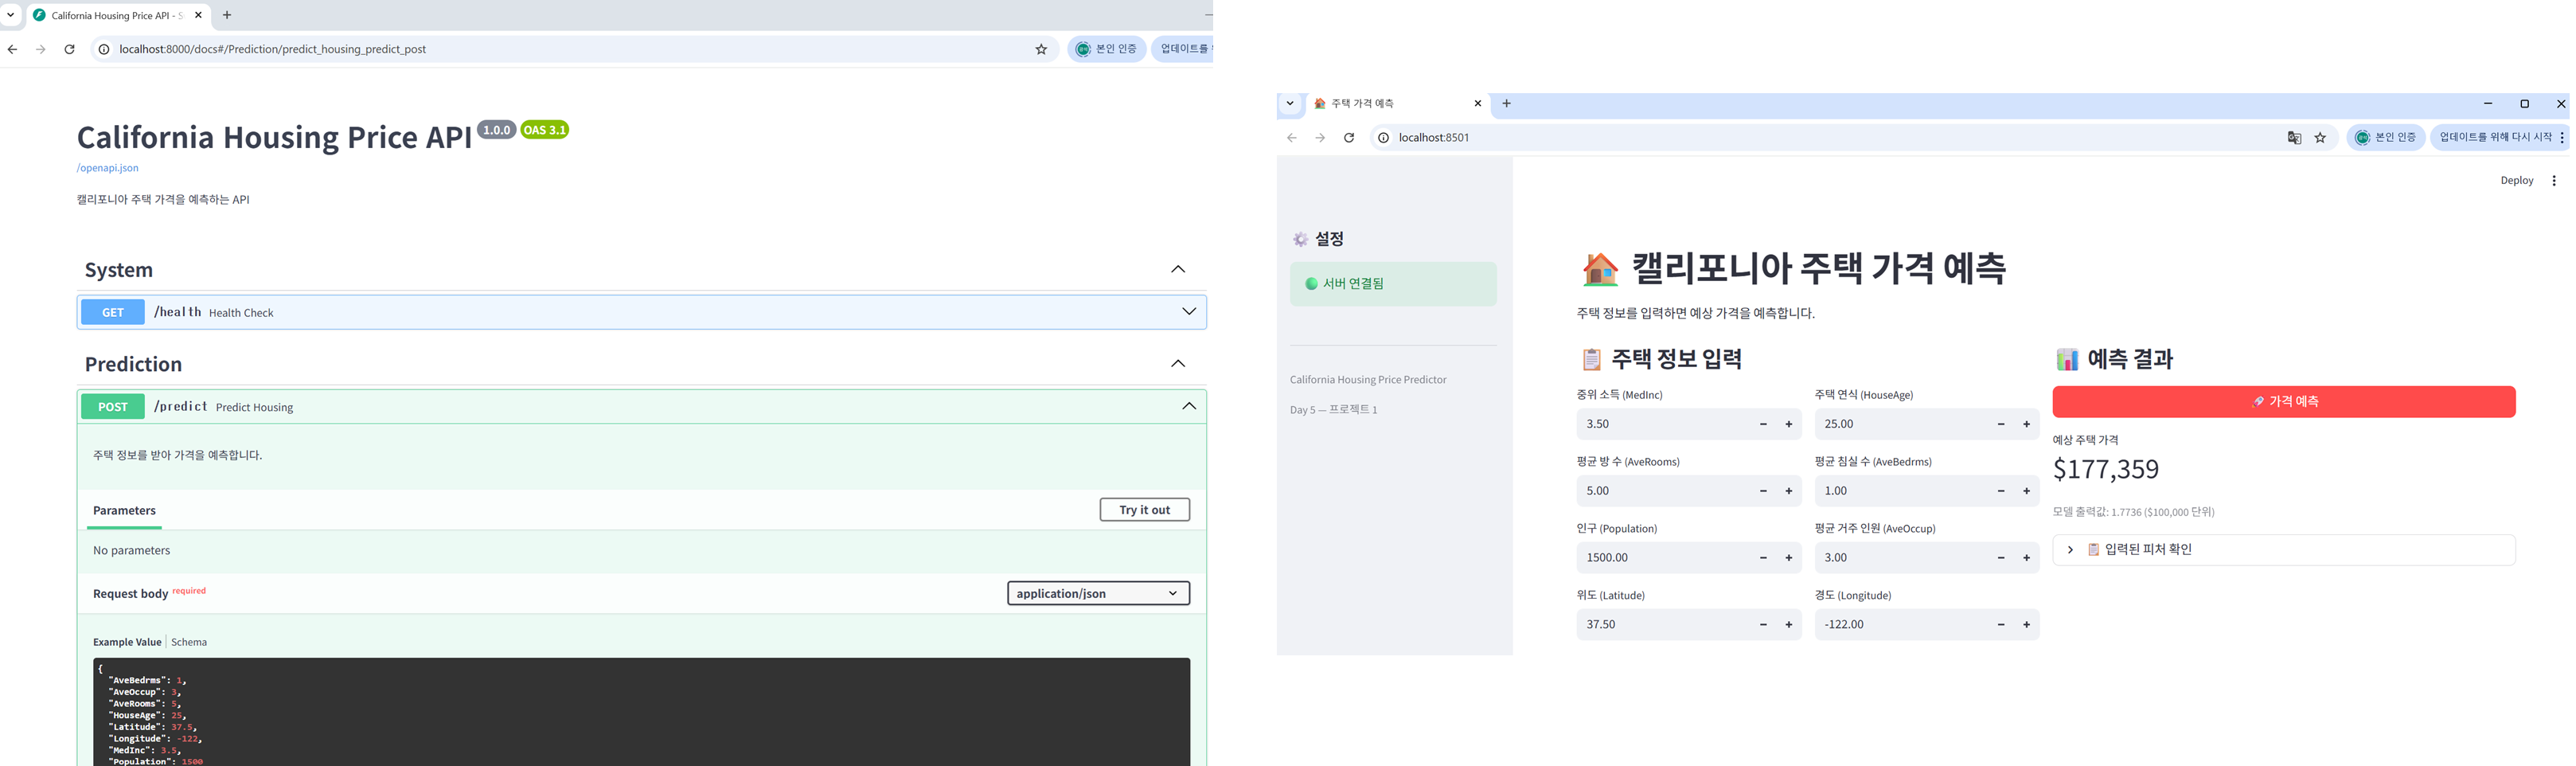

#### 테스트 시나리오

```
[테스트 1] 기본 흐름
  1. 사이드바 서버 상태 🟢 확인
  2. 기본값 그대로 "🚀 가격 예측" 클릭
  3. 예상 가격이 표시되는지 확인

[테스트 2] 값 변경
  1. 중위 소득을 8.0으로 올리기 → 가격 예측 → 가격 상승 확인
  2. 중위 소득을 1.0으로 내리기 → 가격 예측 → 가격 하락 확인

[테스트 3] 에러 상황
  1. 백엔드 서버 종료 → 사이드바 🔴 확인
```

---

### ✅ 체크포인트

1. MNIST 대시보드(Day 4)와 비교했을 때 입력 방식이 어떻게 다릅니까?
2. `st.number_input()`에서 `min_value`, `max_value`를 설정하는 이유는?
3. `request_data` 딕셔너리의 키 이름이 `HousingRequest` 스키마의 필드 이름과 정확히 일치해야 하는 이유는?

---

> **다음 섹션에서는** 전체 서비스를 통합 테스트합니다.

## 5. 통합 테스트 및 디버깅

---

> **학습 목표**
> - 전체 서비스(모델 → API → UI)가 정상 동작하는지 체계적으로 테스트합니다.
> - 다양한 입력으로 모델의 동작을 확인합니다.
> - 에러 상황에서 서버가 안정적으로 동작하는지 검증합니다.

---



### 5.1 API 레벨 통합 테스트

In [ ]:
# ⚠️ FastAPI 서버가 실행 중이어야 합니다.
# 위의 서버 실행 셀을 건너뛰었다면 여기서 한 번 더 확인합니다.

import requests
import json
import time

API_BASE = "http://127.0.0.1:8000"
wait_for_api(f"{API_BASE}/health", timeout=20)

print("=" * 60)
print("  통합 테스트")
print("=" * 60)


✅ API 응답 확인: HTTP 200 — {"status":"healthy","model":"California Housing"}
  통합 테스트


#### 테스트 1: 정상 요청

In [ ]:
# 다양한 입력으로 모델 동작 확인
test_cases = [
    {"name": "저소득 지역", "MedInc": 1.5, "HouseAge": 40, "AveRooms": 4.0, "AveBedrms": 1.0,
     "Population": 2000, "AveOccup": 3.5, "Latitude": 34.0, "Longitude": -118.0},
    {"name": "고소득 지역", "MedInc": 10.0, "HouseAge": 10, "AveRooms": 8.0, "AveBedrms": 2.0,
     "Population": 500, "AveOccup": 2.0, "Latitude": 37.8, "Longitude": -122.4},
    {"name": "평균적 주택", "MedInc": 3.5, "HouseAge": 25, "AveRooms": 5.0, "AveBedrms": 1.0,
     "Population": 1500, "AveOccup": 3.0, "Latitude": 37.5, "Longitude": -122.0},
]

print("\n[테스트 1] 정상 요청 — 다양한 입력")
print(f"{'케이스':<15} {'예측 가격':>12}")
print("-" * 30)

for case in test_cases:
    name = case.pop("name")
    resp = requests.post(f"{API_BASE}/predict", json=case)    # *your code* — POST 요청
    result = resp.json()
    print(f"{name:<15} ${result['predicted_price_usd']:>10,}")
    case["name"] = name  # 복원


[테스트 1] 정상 요청 — 다양한 입력
케이스                    예측 가격
------------------------------
저소득 지역          $   102,060
고소득 지역          $   521,544
평균적 주택          $   177,190


#### 테스트 2: 에러 상황

In [ ]:
print("\n[테스트 2] 에러 상황")

# 필수 필드 누락
resp = requests.post(f"{API_BASE}/predict", json={"MedInc": 3.5})
print(f"  필드 누락      → HTTP {resp.status_code}")

# 범위 초과 (위도)
bad_request = {
    "MedInc": 3.5, "HouseAge": 25, "AveRooms": 5, "AveBedrms": 1,
    "Population": 1500, "AveOccup": 3, "Latitude": 50.0, "Longitude": -122.0,  # 위도 초과
}
resp = requests.post(f"{API_BASE}/predict", json=bad_request)
print(f"  위도 범위 초과  → HTTP {resp.status_code}")

# 음수 값
bad_request2 = {
    "MedInc": -1.0, "HouseAge": 25, "AveRooms": 5, "AveBedrms": 1,
    "Population": 1500, "AveOccup": 3, "Latitude": 37.5, "Longitude": -122.0,
}
resp = requests.post(f"{API_BASE}/predict", json=bad_request2)
print(f"  소득 음수      → HTTP {resp.status_code}")

# JSON이 아닌 요청
resp = requests.post(f"{API_BASE}/predict", data="not json")
print(f"  잘못된 포맷    → HTTP {resp.status_code}")


[테스트 2] 에러 상황
  필드 누락      → HTTP 422
  위도 범위 초과  → HTTP 422
  소득 음수      → HTTP 422
  잘못된 포맷    → HTTP 500


#### 테스트 3: 동시 요청

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_predict(i):
    case = test_cases[i % len(test_cases)].copy()
    case.pop("name", None)
    start = time.time()
    resp = requests.post(f"{API_BASE}/predict", json=case, timeout=30)
    return {"id": i+1, "elapsed": round(time.time() - start, 3), "status": resp.status_code}

print("\n[테스트 3] 동시 요청 (8개)")
start = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = [ex.submit(send_predict, i) for i in range(8)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 2)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/starlette/_exception_handler.py", line 42, in wrapped_app
    await app(scope, receive, sender)
  File "/usr/local/lib/python3.12/dist-packages/fastapi/routing.py", line 120, in app
    response = await f(request)
               ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/routing.py", line 723, in app
    raise validation_error
fastapi.exceptions.RequestValidationError: 1 validation error:
  {'type': 'model_attributes_type', 'loc': ('body',), 'msg': 'Input should be a valid dictionary or object to extract fields from', 'input': b'not json'}

  File "/content/app/housing_api.py", line 61, in predict_housing
    POST /predict

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_as


[테스트 3] 동시 요청 (8개)
  요청 #1: 0.041초 (HTTP 200)
  요청 #2: 0.057초 (HTTP 200)
  요청 #3: 0.043초 (HTTP 200)
  요청 #4: 0.047초 (HTTP 200)
  요청 #5: 0.044초 (HTTP 200)
  요청 #6: 0.045초 (HTTP 200)
  요청 #7: 0.043초 (HTTP 200)
  요청 #8: 0.036초 (HTTP 200)
  전체: 0.07초


#### 테스트 4: 헬스체크

In [ ]:
print("\n[테스트 4] 헬스체크")
resp = requests.get(f"{API_BASE}/health")
print(f"  상태: {resp.json()}")


[테스트 4] 헬스체크
  상태: {'status': 'healthy', 'model': 'California Housing'}


---

### 5.2 테스트 결과 종합

In [ ]:
print("\n" + "=" * 60)
print("  테스트 결과 종합")
print("=" * 60)
print("  ✅ 정상 요청: 다양한 입력에서 합리적인 가격 반환")
print("  ✅ 에러 처리: 잘못된 입력에 422/400 반환, 서버 안 죽음")
print("  ✅ 동시 처리: 8개 동시 요청 정상 처리")
print("  ✅ 헬스체크: 서버 상태 정상")


  테스트 결과 종합
  ✅ 정상 요청: 다양한 입력에서 합리적인 가격 반환
  ✅ 에러 처리: 잘못된 입력에 422/400 반환, 서버 안 죽음
  ✅ 동시 처리: 8개 동시 요청 정상 처리
  ✅ 헬스체크: 서버 상태 정상


---

## 6. 회고: 무엇이 어려웠고, 어떻게 개선할 수 있는가?

---

### 6.1 오늘 만든 것 정리

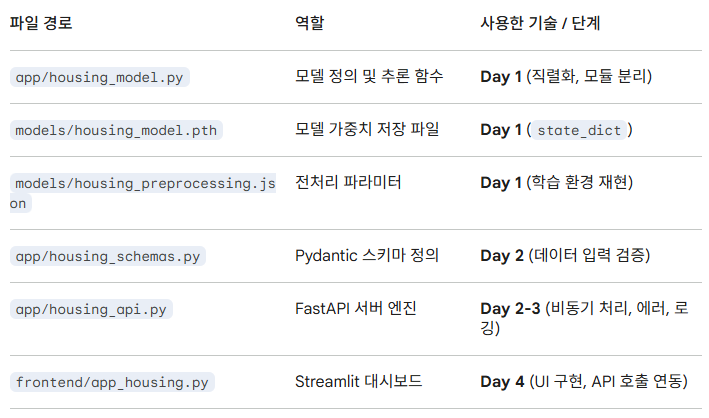



### 6.2 Day 1~4와의 연결



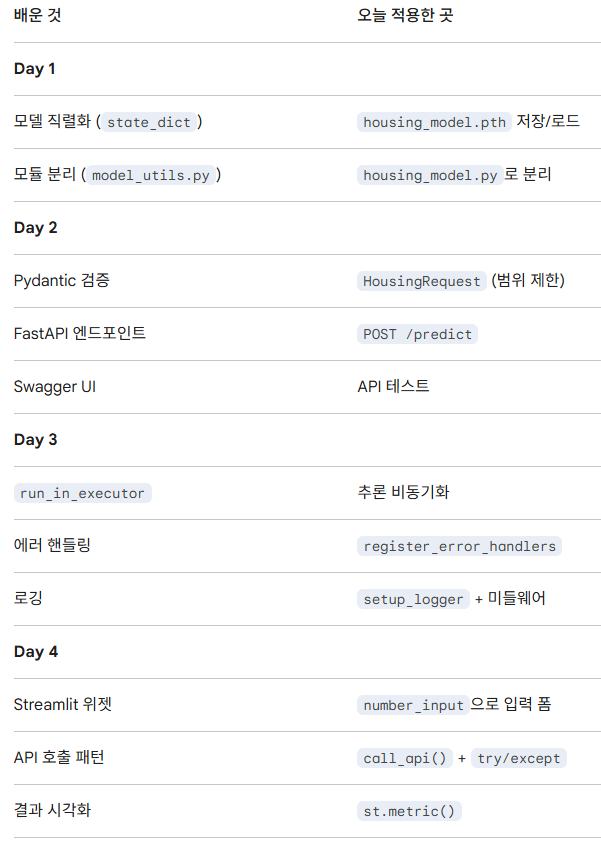

### 6.3 개선할 수 있는 점


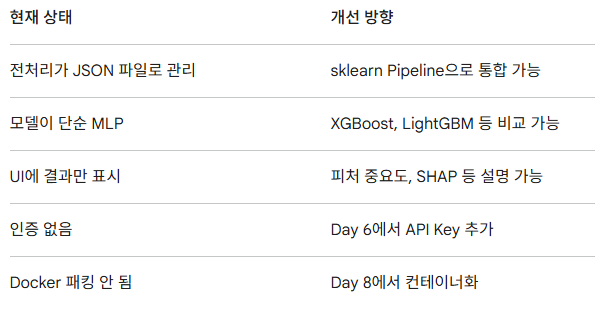



> 이 개선점들은 이 과정의 나머지 Day에서 하나씩 다루거나,
> 이후 MLOps 과정에서 심화합니다.

---

### ✅ Day 5 최종 체크포인트

```
Q1. 전처리 파라미터(mean, std)를 모델과 함께 저장해야 하는 이유는?
Q2. HousingRequest에서 Latitude에 ge=32, le=42를 넣은 이유는?
Q3. Streamlit의 입력값 이름이 Pydantic 스키마의 필드 이름과 일치해야 하는 이유는?
Q4. 이 프로젝트에서 run_in_executor를 제거하면 어떤 문제가 생길 수 있습니까?
Q5. MNIST 프로젝트(Day 1~4)와 오늘 프로젝트의 가장 큰 차이는 무엇입니까?
```

---

### 📌 Day 5 요약

```
오늘 한 일:
  ✅ 캘리포니아 주택 가격 데이터를 탐색하고 전처리 파이프라인을 구성했습니다.
  ✅ PyTorch 회귀 모델을 학습하고 전처리 파라미터와 함께 저장했습니다.
  ✅ FastAPI로 추론 API를 구축했습니다 (Pydantic 검증 + 비동기 처리).
  ✅ Streamlit으로 입력 폼 대시보드를 만들고 API와 연결했습니다.
  ✅ 통합 테스트로 정상/에러/동시 요청을 검증했습니다.
  ✅ Day 1~4의 모든 기술을 하나의 서비스에 통합하는 경험을 했습니다.
```

### 제출

다음 내역을 MD 파일 혹은 노트북 하단에 기록하여, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  
> [제출 링크](https://forms.gle/vwiF5eX7PPB4snzr6)

1. 프로젝트 실행 내역 캡쳐와 설명
2. 각 섹션 체크포인트의 답변
3. 프로젝트 회고

수고하셨습니다!

## 1. 프로젝트 실행 내역 캡쳐와 설명

### 1-1. 데이터 로드 및 탐색
캘리포니아 주택 가격 데이터셋을 불러와 입력 피처 8개와 타겟값을 확인하였다.  
데이터는 총 20,640개 샘플로 구성되어 있으며, 타겟은 중위 주택 가격이다.

### 1-2. 모델 학습
PyTorch 기반 회귀 모델을 정의하고 학습하였다.  
입력값은 8개 피처이며, 출력값은 예측 주택 가격 1개이다.  
학습 과정에서 Epoch가 진행될수록 Loss가 감소하는 것을 확인하였다.



### 1-3. 모델 평가 및 저장
테스트 데이터로 MSE와 MAE를 계산하여 모델 성능을 확인하였다.  
모델 가중치인 `housing_model.pth`와 전처리 파라미터인 `housing_preprocessing.json`을 함께 저장하였다.



### 1-4. FastAPI 서버 실행 및 헬스체크
FastAPI 서버를 실행하고 `/health` 엔드포인트를 호출하여 서버가 정상 동작하는지 확인하였다.




### 1-5. 통합 테스트
정상 요청, 잘못된 입력 요청, 동시 요청, 헬스체크를 수행하여 전체 서비스가 안정적으로 동작하는지 확인하였다.



### 1-6. Streamlit 프론트엔드 실행
Streamlit 대시보드에서 사용자가 숫자 입력 폼을 통해 주택 정보를 입력하고, FastAPI 서버로 요청을 보내 예측 결과를 확인할 수 있었다.



## 2. 각 섹션 체크포인트 답변

---

## 섹션 1 체크포인트

### Q1. 이 프로젝트의 입력과 출력은 각각 무엇입니까?

입력은 캘리포니아 주택 데이터의 8개 숫자형 피처이다.
예를 들어 중위 소득, 주택 연식, 평균 방 수, 평균 침실 수, 인구, 평균 거주 인원, 위도, 경도가 입력된다.
출력은 중위 주택 가격 예측값이며, 회귀 모델이 하나의 숫자 값을 반환한다.

---

### Q2. MNIST 프로젝트와 비교했을 때, 데이터 형태가 어떻게 다릅니까?

MNIST 프로젝트는 이미지 데이터를 입력으로 사용하는 분류 문제였다.
반면 이번 프로젝트는 숫자형 표 형태의 정형 데이터를 입력으로 사용하는 회귀 문제이다.
따라서 이미지 전처리 대신 숫자 피처 정규화가 중요하고, 출력도 클래스가 아니라 연속적인 가격 예측값이다.

---

### Q3. 오늘 새로 만들 파일 3개의 이름과 역할을 말할 수 있습니까?

`housing_model.py`는 주택 가격 예측 모델 구조와 추론 로직을 담는 파일이다.
`housing_schemas.py`는 FastAPI 요청과 응답에 사용할 Pydantic 스키마를 정의하는 파일이다.
`housing_api.py`는 FastAPI 서버와 `/health`, `/predict` 같은 API 엔드포인트를 구현하는 파일이다.

---

## 섹션 2 체크포인트

### Q1. 정규화에서 학습 데이터의 통계를 테스트 데이터에도 사용하는 이유는 무엇입니까?

테스트 데이터는 실제 배포 환경에서 새롭게 들어오는 데이터를 가정한다.
실제 서비스에서는 새로운 데이터 전체의 평균과 표준편차를 미리 알 수 없다.
따라서 학습 시점에 계산한 평균과 표준편차를 기준으로 테스트 데이터와 실제 입력 데이터를 동일하게 변환해야 한다.
이렇게 해야 학습 환경과 추론 환경의 데이터 분포가 일관되게 유지된다.

---

### Q2. 모델 가중치 외에 함께 저장해야 하는 것은 무엇이고, 왜 필요합니까?

모델 가중치 외에 전처리 파라미터를 함께 저장해야 한다.
여기에는 학습 데이터의 평균, 표준편차, 피처 이름과 순서가 포함된다.
이 값들이 없으면 배포 환경에서 입력 데이터를 학습 때와 같은 방식으로 정규화할 수 없고, 그 결과 예측값이 잘못될 수 있다.

---

### Q3. `HousingPredictor.predict()`에서 피처를 `self.feature_names` 순서로 배열하는 이유는?

모델은 학습 당시의 피처 순서를 기준으로 가중치를 학습했다.
따라서 추론할 때도 입력값이 같은 순서로 들어가야 한다.
딕셔너리 입력의 순서가 바뀌더라도 `self.feature_names` 기준으로 배열하면 학습 때와 동일한 피처 순서를 보장할 수 있다.

---

## 섹션 3 체크포인트

### Q1. `HousingRequest`에서 `Latitude`에 `ge=32, le=42` 제한을 넣은 이유는?

캘리포니아 주택 데이터는 캘리포니아 지역의 위도 범위를 기준으로 한다.
따라서 위도가 32보다 작거나 42보다 큰 값은 데이터셋의 범위를 벗어난 비정상 입력일 가능성이 높다.
Pydantic의 `ge`, `le` 제한을 사용하면 잘못된 입력을 API 단계에서 미리 차단할 수 있다.

---

### Q2. `request.model_dump()`는 어떤 역할을 합니까?

`request.model_dump()`는 Pydantic 모델 객체를 일반 파이썬 딕셔너리로 변환한다.
FastAPI에서 받은 요청 객체를 모델 추론 함수에 넘기기 쉬운 형태로 바꾸는 역할을 한다.

---

### Q3. `run_in_executor`를 사용하지 않으면 어떤 문제가 발생할 수 있습니까?

모델 추론은 CPU 연산이 포함된 동기 작업이다.
이를 그대로 비동기 API 함수 안에서 실행하면 이벤트 루프가 막힐 수 있다.
그 결과 동시에 여러 요청이 들어왔을 때 서버 응답이 느려지거나 다른 요청 처리가 지연될 수 있다.
`run_in_executor`를 사용하면 추론 작업을 별도 스레드에서 처리하여 FastAPI 서버의 응답성을 유지할 수 있다.

---

## 섹션 4 체크포인트

### Q1. MNIST 대시보드와 비교했을 때 입력 방식이 어떻게 다릅니까?

MNIST 대시보드는 이미지 파일을 업로드하거나 그림 데이터를 입력하는 방식이었다.
이번 주택 가격 예측 대시보드는 중위 소득, 주택 연식, 방 수, 위도, 경도 같은 숫자형 값을 폼에 입력하는 방식이다.
즉, 이미지 입력 UI에서 정형 데이터 입력 폼 UI로 바뀌었다.

---

### Q2. `st.number_input()`에서 `min_value`, `max_value`를 설정하는 이유는?

사용자가 비현실적이거나 API 스키마에 맞지 않는 값을 입력하지 못하도록 하기 위해서이다.
프론트엔드 단계에서 입력 범위를 제한하면 잘못된 요청을 줄일 수 있고, 사용자 경험도 좋아진다.
또한 백엔드의 Pydantic 검증 조건과 일관성을 맞출 수 있다.

---

### Q3. `request_data` 딕셔너리의 키 이름이 `HousingRequest` 스키마의 필드 이름과 정확히 일치해야 하는 이유는?

FastAPI는 요청 JSON의 키 이름을 Pydantic 스키마의 필드 이름과 매칭하여 검증한다.
키 이름이 다르면 필수 필드가 누락된 것으로 판단되어 422 오류가 발생할 수 있다.
따라서 Streamlit에서 보내는 `request_data`의 키는 `HousingRequest`의 필드 이름과 정확히 일치해야 한다.

---

## Day 5 최종 체크포인트

### Q1. 전처리 파라미터 `mean`, `std`를 모델과 함께 저장해야 하는 이유는?

모델은 정규화된 입력 데이터를 기준으로 학습되었기 때문이다.
배포 환경에서도 같은 평균과 표준편차로 입력 데이터를 정규화해야 모델이 올바른 예측을 할 수 있다.
전처리 파라미터가 없으면 학습 때와 다른 기준으로 입력값이 변환되어 예측 성능이 크게 떨어질 수 있다.

---

### Q2. `HousingRequest`에서 `Latitude`에 `ge=32, le=42`를 넣은 이유는?

캘리포니아 지역 데이터의 위도 범위를 반영하여 잘못된 입력을 제한하기 위해서이다.
모델이 학습하지 않은 범위의 값이 들어오면 예측 신뢰도가 낮아질 수 있으므로, API 스키마 단계에서 입력값을 검증한다.

---

### Q3. Streamlit의 입력값 이름이 Pydantic 스키마의 필드 이름과 일치해야 하는 이유는?

Streamlit에서 만든 JSON 요청이 FastAPI의 Pydantic 스키마로 검증되기 때문이다.
필드 이름이 일치하지 않으면 FastAPI는 해당 값이 없다고 판단하고 422 에러를 반환할 수 있다.

---

### Q4. 이 프로젝트에서 `run_in_executor`를 제거하면 어떤 문제가 생길 수 있습니까?

모델 추론 작업이 FastAPI의 이벤트 루프를 직접 점유할 수 있다.
그 결과 동시에 여러 사용자가 요청할 경우 응답 지연이 발생하거나 서버 처리량이 낮아질 수 있다.
`run_in_executor`는 추론 같은 동기 작업을 별도 스레드에서 실행하여 서버가 다른 요청도 계속 처리할 수 있게 해준다.

---

### Q5. MNIST 프로젝트와 오늘 프로젝트의 가장 큰 차이는 무엇입니까?

MNIST 프로젝트는 이미지 데이터를 입력받아 숫자 클래스를 예측하는 분류 문제였다.
이번 프로젝트는 숫자형 정형 데이터를 입력받아 주택 가격이라는 연속값을 예측하는 회귀 문제이다.
따라서 데이터 전처리, 입력 UI, API 스키마, 모델 출력 해석 방식이 모두 달라졌다.


## 3. 프로젝트 회고

이번 프로젝트를 통해 **단순히 모델을 학습하는 것과 실제 서비스로 배포하는 것은 다르다**는 점을 배웠다.

모델 학습 단계에서는 데이터 전처리, 모델 구조, 손실 함수, 평가 지표가 중요했다.
하지만 배포 단계에서는 단순히 모델 성능만 중요한 것이 아니라, 전처리 파라미터 저장, 입력 스키마 검증, API 엔드포인트 설계, 에러 처리, 동시 요청 처리까지 함께 고려해야 한다는 것을 알게 되었다.


이번 프로젝트는 모델 학습, 저장, API 구현, 입력 검증, 프론트엔드 연결, 통합 테스트까지 하나의 흐름으로 경험할 수 있었다는 점에서 의미가 있었다.
앞으로는 모델 성능을 더 개선하고, 예측 결과에 대한 설명이나 신뢰도 정보를 함께 제공하는 방식으로 발전시켜 보고 싶다.
